In [ ]:
####EXPOSURE 

In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import rtree
import os
import re
import datetime
from operator import itemgetter

def generate_buffered_buildings_for_one_campground(
    hazard_path, 
    buildings_path, 
    geojson_file, 
    polygon_column_name, 
    polygon_name, 
    buffer_meters=None, 
    buffer_percent=100,
    output_folder="Outputs_Events"
):
    """
    Buffers only those buildings that fall inside a selected campground polygon,
    intersects with hazard grid cell centers, and classifies based on depth values.

    Parameters:
    - hazard_path: path to ASCII raster (.asc) to extract grid resolution and depths
    - buildings_path: path to buildings file (must include 'id_def')
    - geojson_file: path to campgrounds GeoJSON
    - polygon_column_name: name of the column with campground names
    - polygon_name: exact name of the campground to select
    - buffer_meters: fixed buffer distance (in meters)
    - buffer_percent: fallback buffer as % of raster resolution if buffer_meters is None
    - output_folder: directory to save outputs

    Returns:
    - GeoDataFrame of classified buildings with 'id_def', depths, and flood class
    """

    T_start = datetime.datetime.now()

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Step 1: Load input data
    campgrounds_gdf = gpd.read_file(geojson_file)
    buildings_gdf = gpd.read_file(buildings_path)

    selected_camp = campgrounds_gdf[campgrounds_gdf[polygon_column_name] == polygon_name]
    if selected_camp.empty:
        raise ValueError(f"No campground found with name: {polygon_name}")
    camp_geom = selected_camp.iloc[0].geometry

    # Step 2: Read ASCII header and build grid
    with open(hazard_path, 'r') as f:
        ncols = int(f.readline().split()[1])
        nrows = int(f.readline().split()[1])
        xllcorner = float(f.readline().split()[1])
        yllcorner = float(f.readline().split()[1])
        cellsize = float(f.readline().split()[1])
        nodata_value = float(f.readline().split()[1])
        data_lines = f.readlines()

    dx = cellsize
    buffer_dist = buffer_meters if buffer_meters is not None else (buffer_percent / 100) * dx

    x_coords = []
    y_coords = []
    Z = []
    for row_idx, line in enumerate(data_lines):
        row_vals = [float(v) for v in re.split(r'\s+', line.strip()) if v]
        for col_idx, val in enumerate(row_vals):
            x_coords.append(xllcorner + col_idx * dx)
            y_coords.append(yllcorner + (nrows - 1 - row_idx) * dx)
            Z.append(val)

    # Step 3: Create spatial index of grid cell centers
    index = rtree.index.Index()
    for i, (xi, yi) in enumerate(zip(x_coords, y_coords)):
        index.insert(i, (xi, yi))

    # Step 4: Filter buildings and apply sharp-edge buffer
    buildings_in_camp = buildings_gdf[buildings_gdf.within(camp_geom)].copy()

    buffer_list = []
    cell_index = []
    buffered_geometries = []

    for _, bldg in buildings_in_camp.iterrows():
        bldg_id = bldg['id_def']
        # Create sharp-corner buffer using cap_style=2 and join_style=2
        buffer = bldg['geometry'].buffer(buffer_dist, resolution=1, cap_style=2, join_style=2)
        buffered_geometries.append(buffer)
        for cell in list(index.intersection(buffer.bounds)):
            pt = Point(x_coords[cell], y_coords[cell])
            if pt.intersects(buffer):
                buffer_list.append(bldg_id)
                cell_index.append(cell)

    buildings_in_camp["geometry"] = buffered_geometries
    buildings_in_camp = gpd.GeoDataFrame(buildings_in_camp, geometry="geometry", crs=buildings_gdf.crs)

    df = pd.DataFrame(list(zip(itemgetter(*cell_index)(Z), buffer_list)), columns=['depth', 'id_def'])

    max_depth = df.groupby('id_def')['depth'].max().round(3).reset_index(name='max_depth')
    mean_depth = df.groupby('id_def')['depth'].mean().round(3).reset_index(name='mean_depth')
    categ_df = pd.merge(max_depth, mean_depth)

    # Step 5: Classification based on thresholds
    categ_df['class'] = 'Low'
    categ_df.loc[(categ_df['mean_depth'] < 0.1) & (categ_df['max_depth'] >= 0.3), 'class'] = 'Medium'
    categ_df.loc[(categ_df['mean_depth'] >= 0.1) & (categ_df['max_depth'] < 0.3), 'class'] = 'Medium'
    categ_df.loc[(categ_df['mean_depth'] >= 0.1) & (categ_df['max_depth'] >= 0.3), 'class'] = 'High'
    categ_df['internally_flooded'] = categ_df['class'] == 'High'

    final_gdf = buildings_in_camp.merge(categ_df, on='id_def', how='left')
    final_gdf['area'] = final_gdf.geometry.area.astype(int)
    final_gdf.fillna({'class': 'Low', 'max_depth': 0.0, 'mean_depth': 0.0, 'internally_flooded': False}, inplace=True)

    # Step 6: Export results
    base_name = os.path.splitext(os.path.basename(hazard_path))[0]
    final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
    final_gdf.drop(columns='geometry').to_csv(f"{output_folder}/{base_name}_floodrisk.csv", index=False)

    with open(f"{output_folder}/{base_name}_summary.txt", 'w') as summary:
        summary.write(f'Summary of Exposure Analysis for: {base_name}\n\n'
                      f'Campground: {polygon_name}\n'
                      f'Building file: {buildings_path}\n\n'
                      f'Number of buildings: {len(buildings_in_camp)}\n'
                      f'Grid resolution: {dx}m\n'
                      f'Buffer distance: {buffer_dist}m\n\n'
                      f"Low: {(final_gdf['class'] == 'Low').sum()}\n"
                      f"Medium: {(final_gdf['class'] == 'Medium').sum()}\n"
                      f"High: {(final_gdf['class'] == 'High').sum()}\n")

    print('Finished. Time required:', str(datetime.datetime.now() - T_start)[:-4])
    return final_gdf, x_coords, y_coords, cell_index


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_intersections_with_grid(
    buffer_gdf, 
    camp_polygon_path, 
    polygon_column_name, 
    polygon_name, 
    buildings_path,
    x_coords, 
    y_coords, 
    cell_index
):
    """
    Visualizes:
    - Original buildings (blue)
    - Buffered buildings (red)
    - Intersected hazard grid points (tiny transparent blue)
    - Campground polygon (black)
    """

    # Load campground polygon
    camp_gdf = gpd.read_file(camp_polygon_path)
    selected_camp = camp_gdf[camp_gdf[polygon_column_name] == polygon_name]

    # Load original building footprints
    buildings_gdf = gpd.read_file(buildings_path)
    buildings_in_camp = buildings_gdf[buildings_gdf.within(selected_camp.iloc[0].geometry)]

    # Extract intersected grid points
    points_x = [x_coords[i] for i in cell_index]
    points_y = [y_coords[i] for i in cell_index]

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 10))
    selected_camp.boundary.plot(ax=ax, color='black', linewidth=1, label='Campground')
    buildings_in_camp.plot(ax=ax, color='lightblue', edgecolor='blue', linewidth=0.7, label='Original Buildings')
    buffer_gdf.boundary.plot(ax=ax, color='red', linewidth=1, label='Buffered Building')
    ax.scatter(points_x, points_y, s=2, color='blue', alpha=0.4, label='Intersected Grid Points')

    ax.set_title(f"Grid Intersection with Buffered Buildings\n{polygon_name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend()
    ax.set_aspect('equal')
    plt.grid(True)
    plt.show()

In [20]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_intersections_with_grid_id(
    buffer_gdf, 
    camp_polygon_path, 
    polygon_column_name, 
    polygon_name, 
    buildings_path,
    x_coords, 
    y_coords, 
    cell_index
):
    """
    Visualizes:
    - Original buildings (blue)
    - Buffered buildings (red)
    - Intersected hazard grid points (tiny transparent blue)
    - Campground polygon (black)
    - Labels each building with its id_def in bold black text
    """

    # Load campground polygon
    camp_gdf = gpd.read_file(camp_polygon_path)
    selected_camp = camp_gdf[camp_gdf[polygon_column_name] == polygon_name]

    # Load original building footprints
    buildings_gdf = gpd.read_file(buildings_path)
    buildings_in_camp = buildings_gdf[buildings_gdf.within(selected_camp.iloc[0].geometry)]

    # Extract intersected grid points
    points_x = [x_coords[i] for i in cell_index]
    points_y = [y_coords[i] for i in cell_index]

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 10))
    selected_camp.boundary.plot(ax=ax, color='black', linewidth=1, label='Campground')
    buildings_in_camp.plot(ax=ax, color='lightblue', edgecolor='blue', linewidth=0.7, label='Original Buildings')
    buffer_gdf.boundary.plot(ax=ax, color='red', linewidth=1, label='Buffered Building')
    ax.scatter(points_x, points_y, s=2, color='blue', alpha=0.4, label='Intersected Grid Points')

    # ➕ Add bold black labels for each building's id_def
    if "id_def" in buildings_in_camp.columns:
        for _, row in buildings_in_camp.iterrows():
            centroid = row.geometry.centroid
            ax.text(
                centroid.x + 5, 
                centroid.y + 5, 
                str(int(row["id_def"])), 
                fontsize=8, 
                color="black", 
                fontweight="bold", 
                alpha=0.9
            )

    ax.set_title(f"Grid Intersection with Buffered Buildings\n{polygon_name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend()
    ax.set_aspect('equal')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_intersections_with_grid_id(
    buffer_gdf, 
    camp_polygon_path, 
    polygon_column_name, 
    polygon_name, 
    buildings_path,
    x_coords, 
    y_coords, 
    cell_index
):
    """
    Visualizes:
    - Original buildings (blue)
    - Buffered buildings (red)
    - Intersected hazard grid points (tiny transparent blue)
    - Campground polygon (black)
    - Labels each building with its id_def in bold black text
    """

    # Load campground polygon
    camp_gdf = gpd.read_file(camp_polygon_path)

    # Normalize and search
    camp_gdf["__cmp"] = camp_gdf[polygon_column_name].str.strip().str.lower()
    polygon_name_clean = polygon_name.strip().lower()
    selected_camp = camp_gdf[camp_gdf["__cmp"] == polygon_name_clean]

    if selected_camp.empty:
        available = camp_gdf["__cmp"].unique()
        raise ValueError(
            f"❌ Campground name '{polygon_name}' not found.\n"
            f"🧩 Available names (normalized):\n{available}"
        )

    # Drop helper column
    camp_gdf.drop(columns="__cmp", inplace=True)

    # Load original building footprints
    buildings_gdf = gpd.read_file(buildings_path)
    buildings_in_camp = buildings_gdf[buildings_gdf.within(selected_camp.iloc[0].geometry)]

    # Extract intersected grid points
    points_x = [x_coords[i] for i in cell_index]
    points_y = [y_coords[i] for i in cell_index]

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 10))
    selected_camp.boundary.plot(ax=ax, color='black', linewidth=1, label='Campground')
    buildings_in_camp.plot(ax=ax, color='lightblue', edgecolor='blue', linewidth=0.7, label='Original Buildings')
    buffer_gdf.boundary.plot(ax=ax, color='red', linewidth=1, label='Buffered Building')
    ax.scatter(points_x, points_y, s=2, color='blue', alpha=0.4, label='Intersected Grid Points')

    # ➕ Add bold black labels for each building's id_def
    if "id_def" in buildings_in_camp.columns:
        for _, row in buildings_in_camp.iterrows():
            centroid = row.geometry.centroid
            ax.text(
                centroid.x + 5, 
                centroid.y + 5, 
                str(int(row["id_def"])), 
                fontsize=8, 
                color="black", 
                fontweight="bold", 
                alpha=0.9
            )

    ax.set_title(f"Grid Intersection with Buffered Buildings\n{polygon_name.strip()}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend()
    ax.set_aspect('equal')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
#### Multiple Scenarios of the Flood Exposure  
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import rtree
import os
import re
import datetime
from operator import itemgetter

def process_multiple_hazard_files(
    hazard_paths,
    buildings_path,
    geojson_file,
    polygon_column_name,
    polygon_name,
    buffer_meters=None,
    buffer_percent=100,
    output_folder="Outputs_Events"
):
    all_results = []

    for hazard_path in hazard_paths:
        print(f"Processing: {hazard_path}")
        T_start = datetime.datetime.now()

        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        campgrounds_gdf = gpd.read_file(geojson_file)
        buildings_gdf = gpd.read_file(buildings_path)

        selected_camp = campgrounds_gdf[campgrounds_gdf[polygon_column_name] == polygon_name]
        if selected_camp.empty:
            raise ValueError(f"No campground found with name: {polygon_name}")
        camp_geom = selected_camp.iloc[0].geometry

        with open(hazard_path, 'r') as f:
            ncols = int(f.readline().split()[1])
            nrows = int(f.readline().split()[1])
            xllcorner = float(f.readline().split()[1])
            yllcorner = float(f.readline().split()[1])
            cellsize = float(f.readline().split()[1])
            nodata_value = float(f.readline().split()[1])
            data_lines = f.readlines()

        dx = cellsize
        buffer_dist = buffer_meters if buffer_meters is not None else (buffer_percent / 100) * dx

        x_coords = []
        y_coords = []
        Z = []
        for row_idx, line in enumerate(data_lines):
            row_vals = [float(v) for v in re.split(r'\s+', line.strip()) if v]
            for col_idx, val in enumerate(row_vals):
                x_coords.append(xllcorner + col_idx * dx)
                y_coords.append(yllcorner + (nrows - 1 - row_idx) * dx)
                Z.append(val)

        index = rtree.index.Index()
        for i, (xi, yi) in enumerate(zip(x_coords, y_coords)):
            index.insert(i, (xi, yi))

        buildings_in_camp = buildings_gdf[buildings_gdf.within(camp_geom)].copy()

        buffer_list = []
        cell_index = []
        buffered_geometries = []

        for _, bldg in buildings_in_camp.iterrows():
            bldg_id = bldg['id_def']
            buffer = bldg['geometry'].buffer(buffer_dist, resolution=1, cap_style=2, join_style=2)
            buffered_geometries.append(buffer)
            for cell in list(index.intersection(buffer.bounds)):
                pt = Point(x_coords[cell], y_coords[cell])
                if pt.intersects(buffer):
                    buffer_list.append(bldg_id)
                    cell_index.append(cell)

        buildings_in_camp["geometry"] = buffered_geometries
        buildings_in_camp = gpd.GeoDataFrame(buildings_in_camp, geometry="geometry", crs=buildings_gdf.crs)

        df = pd.DataFrame(list(zip(itemgetter(*cell_index)(Z), buffer_list)), columns=['depth', 'id_def'])

        max_depth = df.groupby('id_def')['depth'].max().round(3).reset_index(name='max_depth')
        mean_depth = df.groupby('id_def')['depth'].mean().round(3).reset_index(name='mean_depth')
        categ_df = pd.merge(max_depth, mean_depth)

        categ_df['class'] = 'Low'
        categ_df.loc[(categ_df['mean_depth'] < 0.1) & (categ_df['max_depth'] >= 0.3), 'class'] = 'Medium'
        categ_df.loc[(categ_df['mean_depth'] >= 0.1) & (categ_df['max_depth'] < 0.3), 'class'] = 'Medium'
        categ_df.loc[(categ_df['mean_depth'] >= 0.1) & (categ_df['max_depth'] >= 0.3), 'class'] = 'High'
        categ_df['internally_flooded'] = categ_df['class'] == 'High'

        final_gdf = buildings_in_camp.merge(categ_df, on='id_def', how='left')
        final_gdf['area'] = final_gdf.geometry.area.astype(int)
        final_gdf.fillna({'class': 'Low', 'max_depth': 0.0, 'mean_depth': 0.0, 'internally_flooded': False}, inplace=True)

        scenario = int(re.findall(r'_(\d+)_1h', hazard_path)[0])
        final_gdf['scenario'] = scenario

        final_gdf = final_gdf[['id_def', 'objectid', 'geometry', 'max_depth', 'mean_depth', 'class', 'internally_flooded', 'area', 'scenario']]
        all_results.append(final_gdf)

        print(f"Finished {scenario}. Time: {str(datetime.datetime.now() - T_start)[:-4]}")

    return pd.concat(all_results, ignore_index=True)

In [ ]:
### SALAVAUX

In [9]:
# Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Salavaux_2m_v2/Salavaux_2m_v2_85_fv1-gpu/Salavaux_2m_v2_75min_85.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/geo_hwr_footp_tlm2023.shp' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/addedpolygons_campingsite_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Salavaux plage "
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_SALAVAUX, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Salavaux plage ",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/buildings_exposed_atcampgrounds/Salavaux_2m_v2"
)

/tmp/ipykernel_749100/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:11.22


In [ ]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_SALAVAUX,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [26]:
## MORGES 
# Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_75_fv1-gpu/Morges_2m_75_1h_75.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Morges"
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_MORGES, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Morges ",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Morges_2m_scenarios/"
)

/tmp/ipykernel_1335235/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:18.20


In [27]:
classified_buildings_MORGES

,id_def,objectid,geometry,max_depth,mean_depth,class,internally_flooded,area
0,1486487,1486487,"POLYGON ((2527087.631 1150792.955, 2527085.11 ...",0.282,0.101,Medium,False,245
1,1486486,1486486,"POLYGON ((2527122.251 1150788.979, 2527118.392...",0.306,0.173,High,True,96
2,1486485,1486485,"POLYGON ((2527093.82 1150770.202, 2527090.175 ...",0.168,0.026,Low,False,183
3,787211,787211,"POLYGON ((2527025.341 1150693.338, 2527028.373...",0.138,0.051,Low,False,287
4,1486488,1486488,"POLYGON ((2527184.782 1150751.681, 2527178.676...",0.068,0.014,Low,False,230
5,1486484,1486484,"POLYGON ((2527041.327 1150729.771, 2527037.91 ...",0.180,0.025,Low,False,217


/tmp/ipykernel_1335235/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


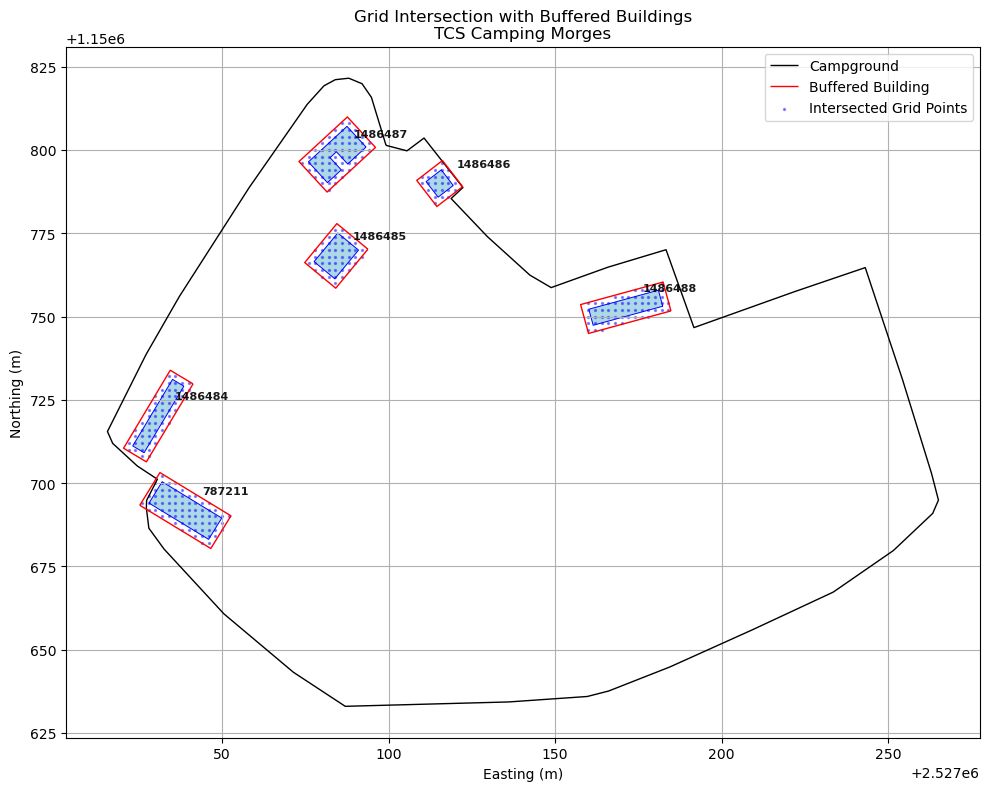

In [28]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_MORGES,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [29]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_15_fv1-gpu/Morges_2m_15_1h_15.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_25_fv1-gpu/Morges_2m_25_1h_25.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_35_fv1-gpu/Morges_2m_35_1h_35.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_45_fv1-gpu/Morges_2m_45_1h_45.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_55_fv1-gpu/Morges_2m_55_1h_55.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_65_fv1-gpu/Morges_2m_65_1h_65.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_75_fv1-gpu/Morges_2m_75_1h_75.max'
]

In [ ]:
Morges_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Morges ",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/buildings_exposed_atcampgrounds/Salavaux_2m_v2"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_15_fv1-gpu/Morges_2m_15_1h_15.max
Finished 15. Time: 0:03:08.78
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_25_fv1-gpu/Morges_2m_25_1h_25.max
Finished 25. Time: 0:03:17.94
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_35_fv1-gpu/Morges_2m_35_1h_35.max
Finished 35. Time: 0:03:16.56
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_45_fv1-gpu/Morges_2m_45_1h_45.max
Finished 45. Time: 0:03:15.67
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_55_fv1-gpu/Morges_2m_55_1h_55.max
Finished 55. Time: 0:03:14.90
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_65_fv1-gpu/Morges_2m_65_1h_65.max
Finished 65. Time: 0:03:17.55
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Morges_2m/Morges_2m_75_fv1-gpu/Morges_2m_75_1h_75.max
Finished 75. Time: 0:03:16.35

/tmp/ipykernel_1335235/589407343.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


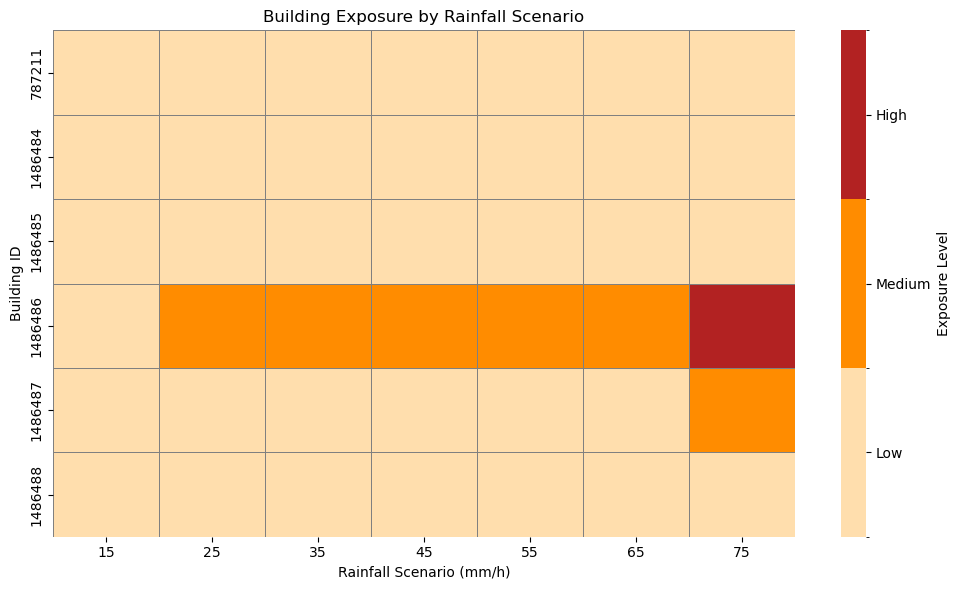

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Morges_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
###SEMPACH 

In [32]:
# Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_18_fv1-gpu/Sempach_2m_18_1h_18.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Sempach"
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_MORGES, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Sempach",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Sempach_2m_scenarios/"
)

/tmp/ipykernel_1335235/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:08.80


/tmp/ipykernel_1335235/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


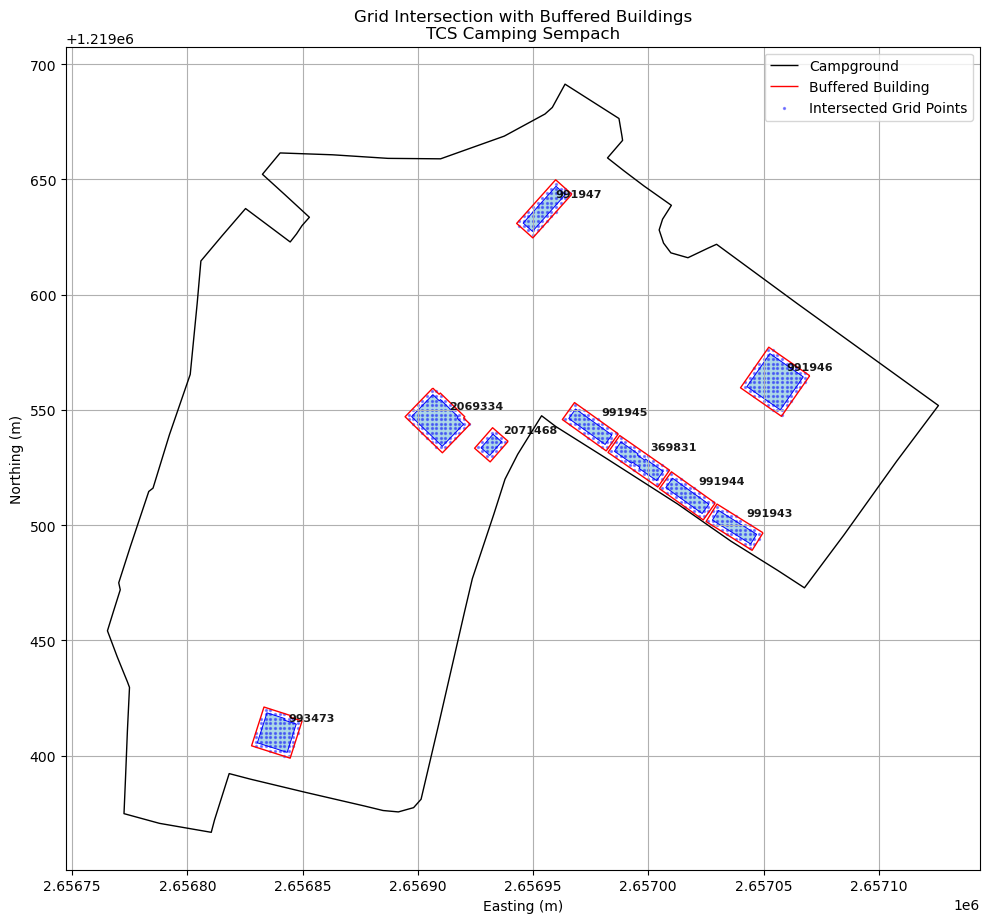

In [34]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_MORGES,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [36]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_18_fv1-gpu/Sempach_2m_18_1h_18.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_28_fv1-gpu/Sempach_2m_28_1h_28.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_38_fv1-gpu/Sempach_2m_38_1h_38.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_48_fv1-gpu/Sempach_2m_48_1h_48.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_58_fv1-gpu/Sempach_2m_58_1h_58.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_68_fv1-gpu/Sempach_2m_68_1h_68.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_78_fv1-gpu/Sempach_2m_78_1h_78.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_88_fv1-gpu/Sempach_2m_88_1h_88.max'
]

In [37]:
Sempach_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Sempach",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Sempach_2m_scenarios"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_18_fv1-gpu/Sempach_2m_18_1h_18.max
Finished 18. Time: 0:03:10.70
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_28_fv1-gpu/Sempach_2m_28_1h_28.max
Finished 28. Time: 0:03:12.63
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_38_fv1-gpu/Sempach_2m_38_1h_38.max
Finished 38. Time: 0:03:14.01
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_48_fv1-gpu/Sempach_2m_48_1h_48.max
Finished 48. Time: 0:03:12.06
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_58_fv1-gpu/Sempach_2m_58_1h_58.max
Finished 58. Time: 0:03:12.85
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_68_fv1-gpu/Sempach_2m_68_1h_68.max
Finished 68. Time: 0:03:13.55
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Sempach_2m/Sempach_2m_78_fv1-gpu/Sempach_2m_78_1h_78.max
Finished

/tmp/ipykernel_1335235/155317063.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


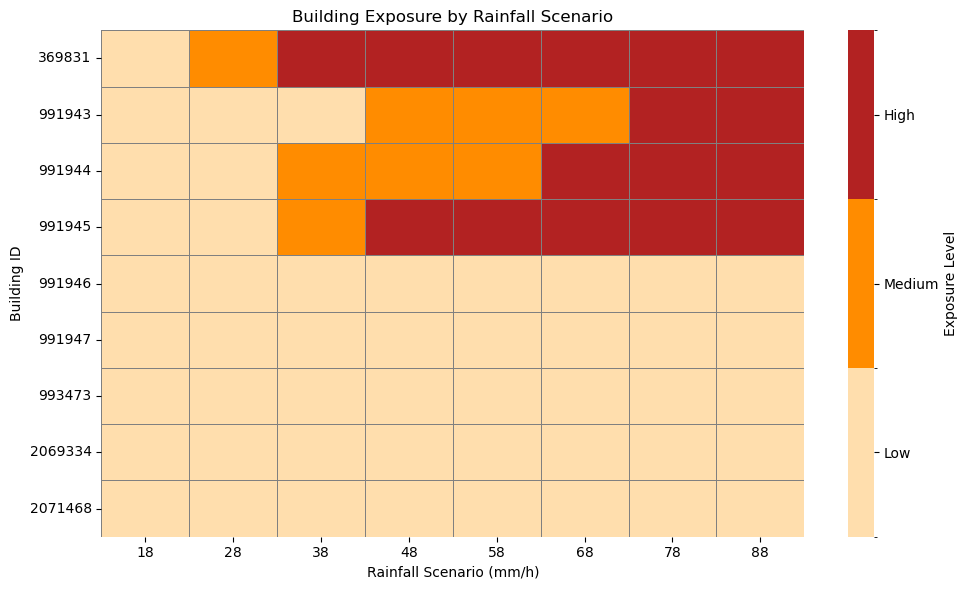

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Sempach_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
### MUZZANO 

In [39]:
 # Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_10_fv1-gpu/Muzzano_2m_10_1h_10.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Lugano-Muzzano"
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_MUZZANO, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Lugano-Muzzano",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Muzzano_2m_scenarios/"
)

/tmp/ipykernel_1335235/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:11.90


/tmp/ipykernel_1335235/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


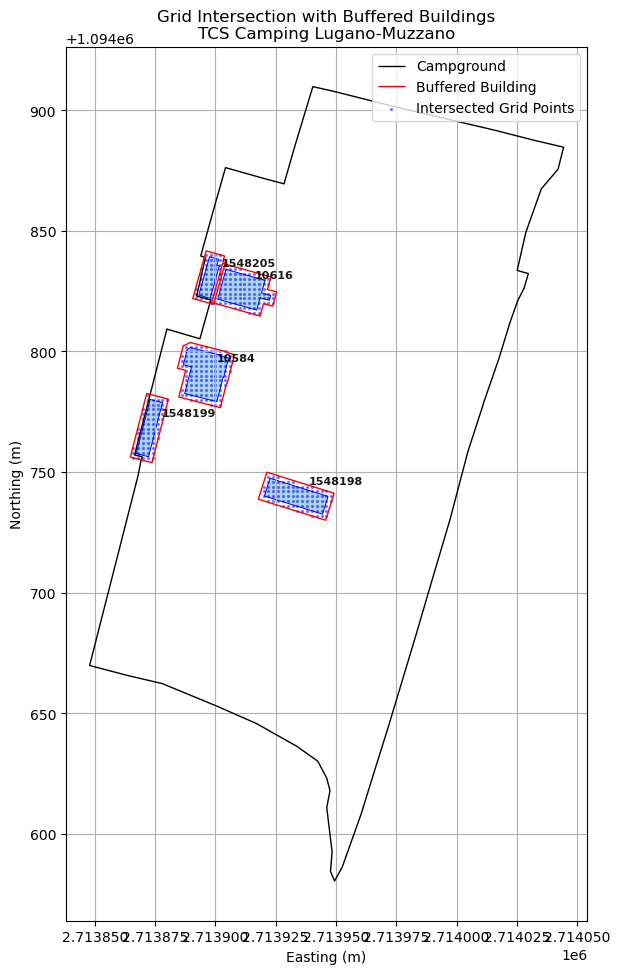

In [40]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_MUZZANO,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [41]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_10_fv1-gpu/Muzzano_2m_10_1h_10.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_20_fv1-gpu/Muzzano_2m_20_1h_20.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_30_fv1-gpu/Muzzano_2m_30_1h_30.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_40_fv1-gpu/Muzzano_2m_40_1h_40.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_50_fv1-gpu/Muzzano_2m_50_1h_50.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_60_fv1-gpu/Muzzano_2m_60_1h_60.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_70_fv1-gpu/Muzzano_2m_70_1h_70.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_80_fv1-gpu/Muzzano_2m_80_1h_80.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_90_fv1-gpu/Muzzano_2m_90_1h_90.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_100_fv1-gpu/Muzzano_2m_100_1h_100.max',
    
]

In [42]:
Muzzano_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Lugano-Muzzano",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Muzzano_2m_scenarios"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_10_fv1-gpu/Muzzano_2m_10_1h_10.max
Finished 10. Time: 0:03:07.23
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_20_fv1-gpu/Muzzano_2m_20_1h_20.max
Finished 20. Time: 0:03:11.61
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_30_fv1-gpu/Muzzano_2m_30_1h_30.max
Finished 30. Time: 0:03:12.71
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_40_fv1-gpu/Muzzano_2m_40_1h_40.max
Finished 40. Time: 0:03:13.26
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_50_fv1-gpu/Muzzano_2m_50_1h_50.max
Finished 50. Time: 0:03:13.99
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_60_fv1-gpu/Muzzano_2m_60_1h_60.max
Finished 60. Time: 0:03:14.06
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Muzzano_2m/Muzzano_2m_70_fv1-gpu/Muzzano_2m_70_1h_70.max
Finished

/tmp/ipykernel_1335235/718203454.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


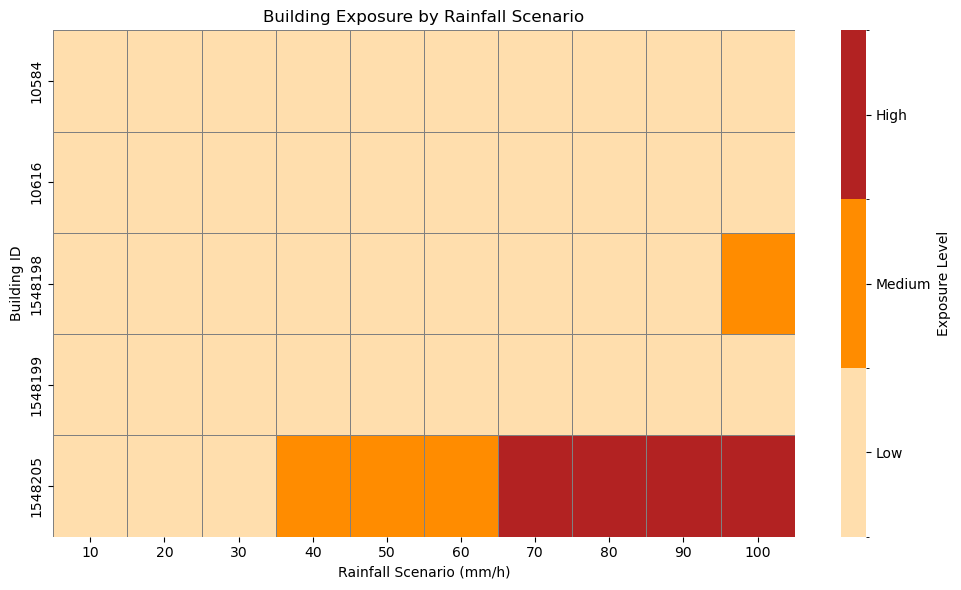

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Muzzano_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
## INTERLAKEN 

In [49]:
 # Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_10_fv1-gpu/Interlaken_2m_10_1h_10.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Interlaken "
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_INTERLAKEN, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Interlaken ",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Interlaken_2m_scenarios/"
)

/tmp/ipykernel_1335235/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:11.30


/tmp/ipykernel_1335235/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


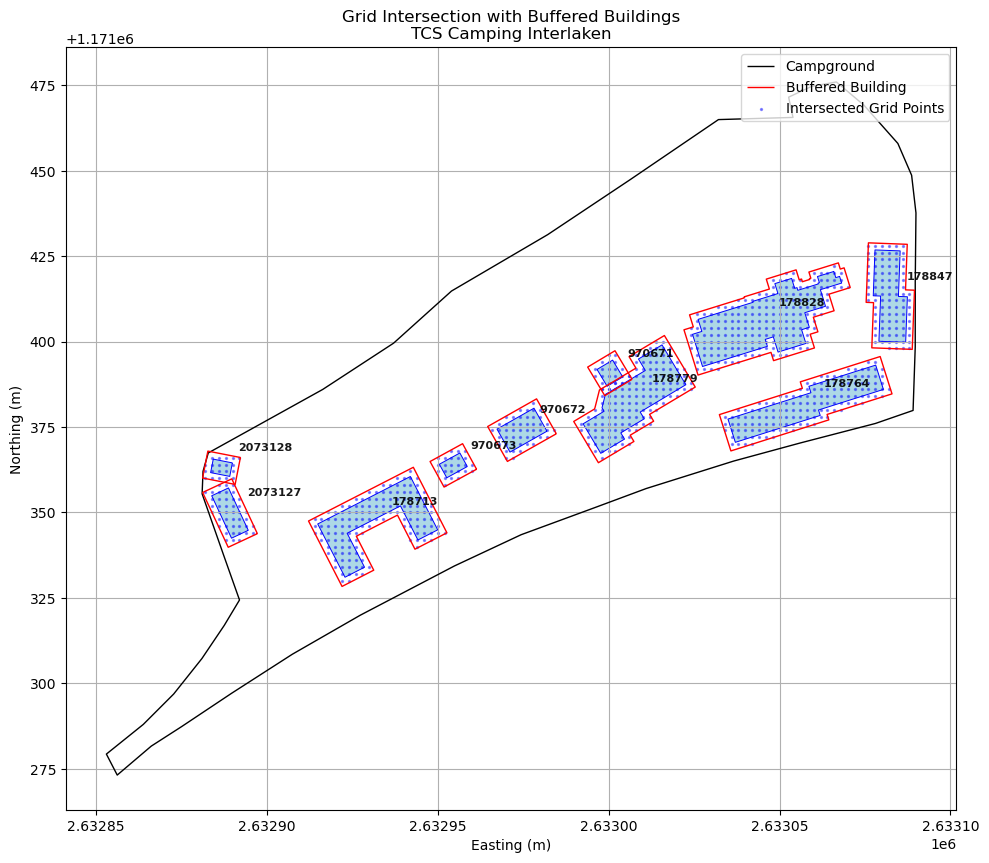

In [50]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_INTERLAKEN,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [51]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_10_fv1-gpu/Interlaken_2m_10_1h_10.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_20_fv1-gpu/Interlaken_2m_20_1h_20.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_30_fv1-gpu/Interlaken_2m_30_1h_30.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_40_fv1-gpu/Interlaken_2m_40_1h_40.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_50_fv1-gpu/Interlaken_2m_50_1h_50.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_60_fv1-gpu/Interlaken_2m_60_1h_60.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_70_fv1-gpu/Interlaken_2m_70_1h_70.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_80_fv1-gpu/Interlaken_2m_80_1h_80.max'
    
]

In [52]:
Interlaken_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Interlaken ",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Interlaken_2m_scenarios"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_10_fv1-gpu/Interlaken_2m_10_1h_10.max
Finished 10. Time: 0:03:08.27
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_20_fv1-gpu/Interlaken_2m_20_1h_20.max
Finished 20. Time: 0:03:17.98
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_30_fv1-gpu/Interlaken_2m_30_1h_30.max
Finished 30. Time: 0:03:19.30
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_40_fv1-gpu/Interlaken_2m_40_1h_40.max
Finished 40. Time: 0:03:17.48
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_50_fv1-gpu/Interlaken_2m_50_1h_50.max
Finished 50. Time: 0:03:17.49
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_2m/Interlaken_2m_60_fv1-gpu/Interlaken_2m_60_1h_60.max
Finished 60. Time: 0:03:16.96
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Interlaken_

/tmp/ipykernel_1335235/587811540.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


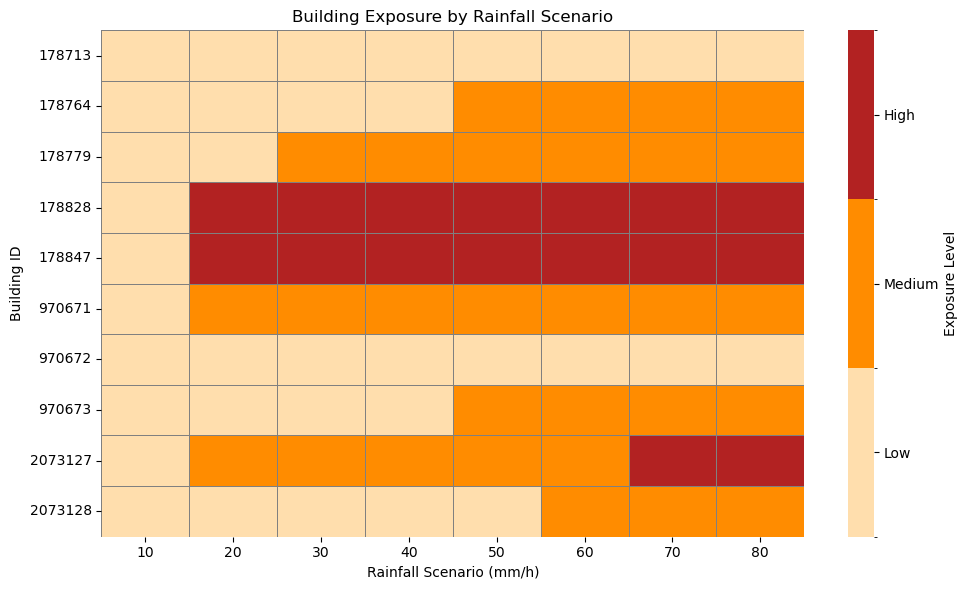

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Interlaken_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
##### AAREGG

In [7]:
 # Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_10_fv1-gpu/Aaregg_2m_10_1h_10.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="Camping Aaregg"
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_AAREGG, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="Camping Aaregg",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Aaregg_2m_scenarios/"
)

/tmp/ipykernel_2253376/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:03:21.56


/tmp/ipykernel_2253376/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


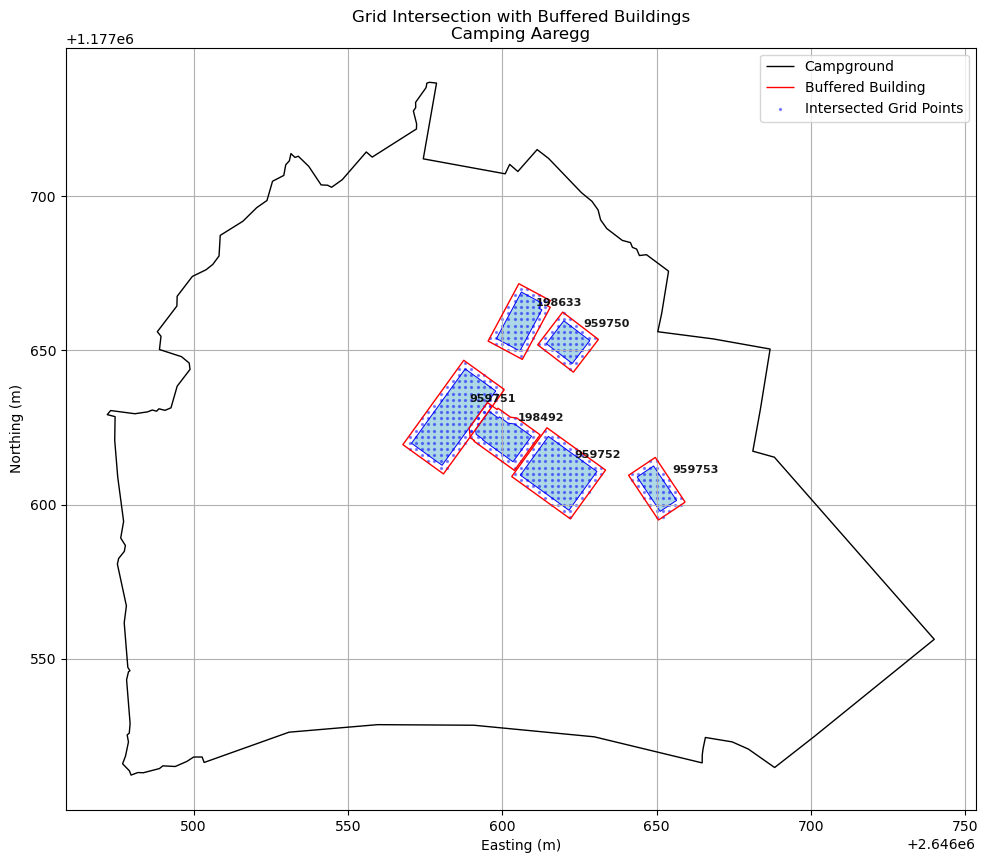

In [8]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_AAREGG,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [9]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_10_fv1-gpu/Aaregg_2m_10_1h_10.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_20_fv1-gpu/Aaregg_2m_20_1h_20.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_30_fv1-gpu/Aaregg_2m_30_1h_30.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_40_fv1-gpu/Aaregg_2m_40_1h_40.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_50_fv1-gpu/Aaregg_2m_50_1h_50.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_60_fv1-gpu/Aaregg_2m_60_1h_60.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_70_fv1-gpu/Aaregg_2m_70_1h_70.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_80_fv1-gpu/Aaregg_2m_80_1h_80.max'
    
]

In [10]:
Aaregg_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="Camping Aaregg",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Aaregg_2m_scenarios"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_10_fv1-gpu/Aaregg_2m_10_1h_10.max
Finished 10. Time: 0:03:15.96
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_20_fv1-gpu/Aaregg_2m_20_1h_20.max
Finished 20. Time: 0:03:18.06
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_30_fv1-gpu/Aaregg_2m_30_1h_30.max
Finished 30. Time: 0:03:16.38
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_40_fv1-gpu/Aaregg_2m_40_1h_40.max
Finished 40. Time: 0:03:13.92
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_50_fv1-gpu/Aaregg_2m_50_1h_50.max
Finished 50. Time: 0:03:14.07
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_60_fv1-gpu/Aaregg_2m_60_1h_60.max
Finished 60. Time: 0:03:13.39
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Aaregg_2m/Aaregg_2m_70_fv1-gpu/Aaregg_2m_70_1h_70.max
Finished 70. Time: 0:03:11.85

/tmp/ipykernel_2253376/3105201817.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


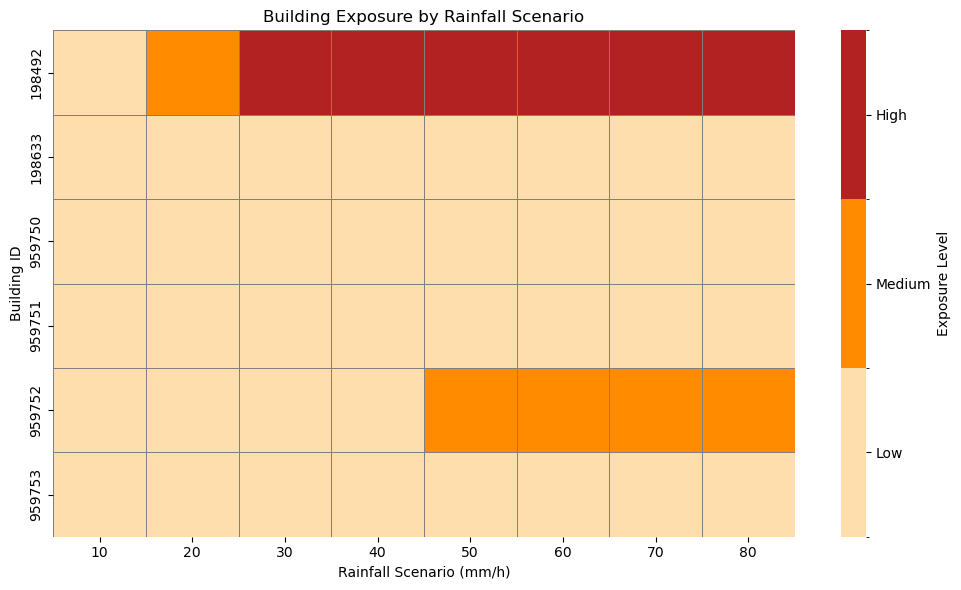

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Aaregg_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
### BERN 

In [12]:
 # Call the function
hazard_path='/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_10_fv1-gpu/Bern_2m_10_1h_10.max'
buildings_path ='/rs_scratch/users/ge24z347/Data_forprocess/building_footprint_2023.gpkg' 
campgrounds_path = '/rs_scratch/users/ge24z347/Data_forprocess/polygon_campsites_391.geojson'
polygon_column_name="Campingplaetze_excel_finshed_Campingplatz"
polygon_name="TCS Camping Bern Eymatt"
#classified_buildings = generate_buffered_buildings_for_one_campground(
#    hazard_path=hazard_path,
#    buildings_path=buildings_path,
#    geojson_file=campgrounds_path,
#    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
#    polygon_name="TCS Camping Gordevio -Maggiatal ",
#    buffer_meters=6,  # Use 100 meters buffer around buildings
#    output_folder="/rs_scratch/users/ge24z347/Gordevio_exposure"
#)
classified_buildings_BERN, x_coords, y_coords, cell_index = generate_buffered_buildings_for_one_campground(
    hazard_path=hazard_path,
    buildings_path=buildings_path,
    geojson_file=campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Bern Eymatt",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Bern_2m_scenarios/"
)

/tmp/ipykernel_2253376/222497051.py:120: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  final_gdf.to_file(f"{output_folder}/{base_name}_floodrisk.shp")
/storage/homefs/ge24z347/mambaforge/envs/env_py311/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'internally_flooded' to 'internally'
  ogr_write(


Finished. Time required: 0:04:02.04


/tmp/ipykernel_2253376/1941750842.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


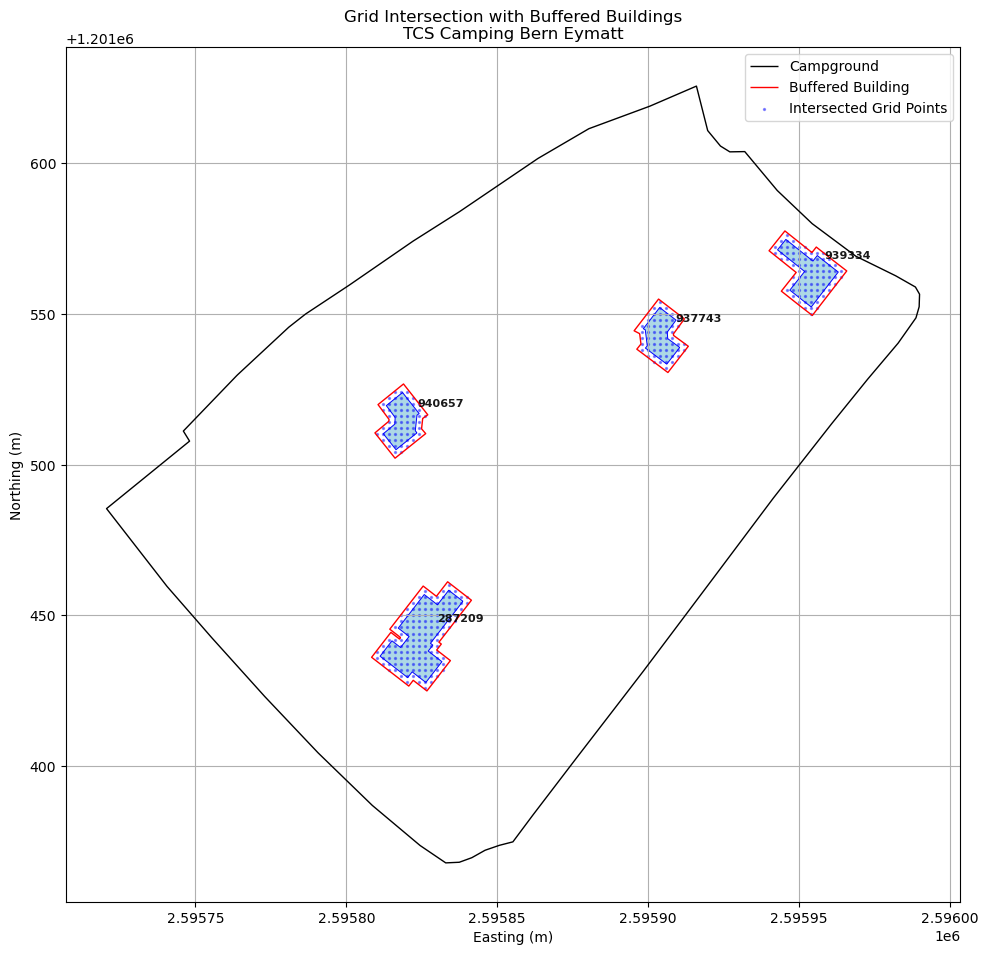

In [13]:
plot_intersections_with_grid_id(
    buffer_gdf=classified_buildings_BERN,
    camp_polygon_path=campgrounds_path,
    polygon_column_name=polygon_column_name,
    polygon_name=polygon_name,
    buildings_path=buildings_path,
    x_coords=x_coords,
    y_coords=y_coords,
    cell_index=cell_index
)

In [14]:
## HAZARD PATHS TO DEFINE 
hazard_paths = [
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_10_fv1-gpu/Bern_2m_10_1h_10.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_20_fv1-gpu/Bern_2m_20_1h_20.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_30_fv1-gpu/Bern_2m_30_1h_30.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_40_fv1-gpu/Bern_2m_40_1h_40.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_50_fv1-gpu/Bern_2m_50_1h_50.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_60_fv1-gpu/Bern_2m_60_1h_60.max',
    '/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_70_fv1-gpu/Bern_2m_70_1h_70.max'
    
]

In [15]:
Bern_exp= process_multiple_hazard_files(
    hazard_paths = hazard_paths,
    buildings_path = buildings_path,
    geojson_file =campgrounds_path,
    polygon_column_name="Campingplaetze_excel_finshed_Campingplatz",
    polygon_name="TCS Camping Bern Eymatt",
    buffer_meters=2,
    output_folder="/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Bern_2m_scenarios"
)

Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_10_fv1-gpu/Bern_2m_10_1h_10.max
Finished 10. Time: 0:03:10.24
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_20_fv1-gpu/Bern_2m_20_1h_20.max
Finished 20. Time: 0:03:13.04
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_30_fv1-gpu/Bern_2m_30_1h_30.max
Finished 30. Time: 0:03:12.15
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_40_fv1-gpu/Bern_2m_40_1h_40.max
Finished 40. Time: 0:03:11.94
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_50_fv1-gpu/Bern_2m_50_1h_50.max
Finished 50. Time: 0:03:11.97
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_60_fv1-gpu/Bern_2m_60_1h_60.max
Finished 60. Time: 0:03:11.76
Processing: /storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bern_2m/Bern_2m_70_fv1-gpu/Bern_2m_70_1h_70.max
Finished 70. Time: 0:03:13.47


/tmp/ipykernel_2253376/2919405650.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pivot.replace(class_to_color)


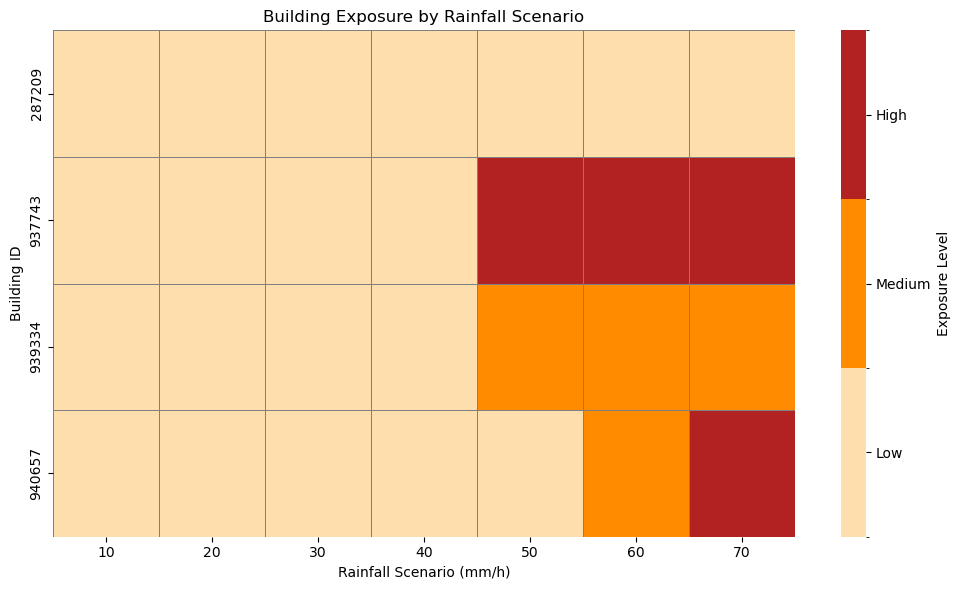

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Pivot the data
pivot = Bern_exp.pivot(index='id_def', columns='scenario', values='class')

# Mapping classes to numeric codes
class_to_color = {"Low": 0, "Medium": 1, "High": 2}
color_labels = ["Low", "Medium", "High"]
color_palette = ["navajowhite", "darkorange", "firebrick"]

heatmap_data = pivot.replace(class_to_color)

# Create a custom colormap and norm
cmap = mcolors.ListedColormap(color_palette)
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': [0, 1, 2], 'label': 'Exposure Level'},
    linewidths=0.5,
    linecolor='gray'
)

# Set colorbar tick labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(color_labels)

# Fix x-tick alignment
ax.set_xticks([i + 0.5 for i in range(len(heatmap_data.columns))])
ax.set_xticklabels(heatmap_data.columns)

# Labels
plt.title("Building Exposure by Rainfall Scenario")
plt.xlabel("Rainfall Scenario (mm/h)")
plt.ylabel("Building ID")
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
### example for power point 

Total accumulation over 60 min: 78.60 mm
Total accumulation over 75 min (zeros appended): 78.60 mm


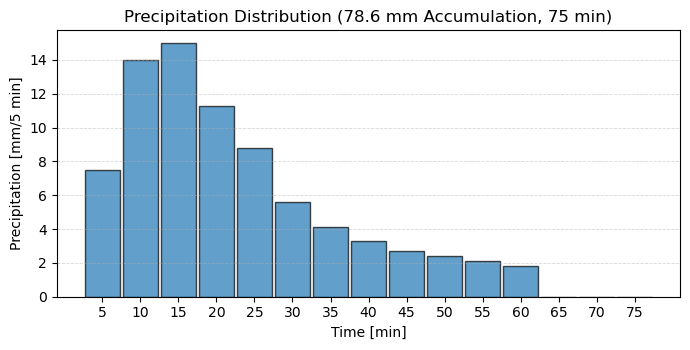

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- INPUT: mm per 5-minute bin for 5..60 min (12 values) ---
# Replace these with your actual numbers used for the 60-min chart.
precip_60min = [
    7.5, 14.0, 15.0, 11.3, 8.8, 5.6, 4.1, 3.3, 2.7, 2.4, 2.1, 1.8
]

# Optional: set a title total for display (not used in calculations)
title_total_mm = round(sum(precip_60min), 1)  # e.g., 79.0

# --- Build the 75-min series: same first 60 min, then zeros at 65, 70, 75 ---
times_75 = list(range(5, 80, 5))  # 5,10,...,75
precip_75min = precip_60min + [0.0, 0.0, 0.0]  # add bins at 65, 70, 75

# Sanity checks
assert len(precip_60min) == 12, "Expected 12 bins for 5..60 min."
assert len(precip_75min) == 15 and len(times_75) == 15, "75-min series should have 15 bins."

total_60 = sum(precip_60min)
total_75 = sum(precip_75min)  # should be the same as total_60

print(f"Total accumulation over 60 min: {total_60:.2f} mm")
print(f"Total accumulation over 75 min (zeros appended): {total_75:.2f} mm")

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.0, 3.6))  # ~ similar aspect to your image

ax.bar(times_75, precip_75min, width=4.5, edgecolor="black", alpha=0.7)
ax.set_xlabel("Time [min]")
ax.set_ylabel("Precipitation [mm/5 min]")
ax.set_title(f"Precipitation Distribution ({title_total_mm} mm Accumulation, 75 min)")

ax.set_xticks(times_75)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.savefig("hyetograph_75min.png", dpi=200)
plt.show()